# PDAN8411 — POE Part 2: Classification
### Predicting Cancer Diagnosis for Medical Aid Dreaded Disease Benefits


Steps for Analysis on the Data
1. Import Libraries
2. Load and Inspect the Data
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Feature Selection
5. Build Classification Models
6. Evaluate and Compare Models
7. Model Comparison Summary

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

## 2. Load the Dataset

In [3]:
df = pd.read_csv('cancer.csv')

# The CSV has a trailing comma in the header row which creates an empty Unnamed column
# This column is dropped immediately as it contains no data
if df.columns[-1].startswith('Unnamed'):
    df = df.drop(columns=[df.columns[-1]])

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Initial Data Inspection

Before conducting any analysis or making any transformations, it is essential to understand the raw structure of the dataset. 
This section examines the number of records and features, the data types of each column, the presence of any missing values, and whether any duplicate rows exist. All inspections are performed on the unmodified data so that the findings accurately reflect the dataset as it was originally sourced.

In [4]:
# show the number of rows and columns in the dataset
df.shape

(569, 32)

### DataFrame Shape

The dataset contains 569 rows and 32 columns. This confirms that the cancer.csv file loaded correctly with the full set of patient records, all 30 feature columns, the id column, and the diagnosis target column.

In [5]:
# show the column names, data types and whether there are null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### DataFrame Information

The info() function gives us a structural overview of the dataset. It shows the number of entries, the column names, the data types of each column, and whether there are any null or missing values.

From the output we can see that all 32 columns show 569 non-null entries, confirming that there are no missing values anywhere in the dataset. The diagnosis column is of object type and will need to be encoded before model training. All 30 feature columns are of float64 type, and the id column is an integer. The complete absence of null values across all columns is a significant quality indicator and removes the need for any imputation strategy.

In [6]:
# statistical summary for all numerical columns
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Descriptive Statistics

The describe() function returns eight summary statistics for every numerical column — count, mean, standard deviation, minimum, the three quartiles (25%, 50%, 75%), and maximum. 

**Count** confirms that every column shows 569 non-null entries, which is consistent with the isnull() check above and confirms there are no missing values anywhere in the dataset.
**Mean** is the average value across all 569 records and immediately highlights the scale disparity in this dataset. The mean of area_mean is approximately 654, the mean of radius_mean is approximately 14, and the mean of fractal_dimension_mean is approximately 0.063. These features measure completely different things in completely different units, and the mean of area_mean is roughly 10 000 times larger than the mean of fractal_dimension_mean. 
**Standard deviation (std)** The most striking example is area_worst, which has a mean of approximately 881 but a standard deviation of approximately 569, the spread is more than half the mean, indicating enormous variability between patients.The smoothness_worst in comparison has a mean of 0.132 and a standard deviation of only 0.023, meaning almost all values fall within a very tight band. This contrast in spread across features is another reason scaling is essential before training.
**Minimum** shows the smallest recorded value for each feature. concavity_mean and concave points_mean have a minimum of exactly 0, which is not a data error but a biologically valid measurement indicating that some tumours in the dataset have perfectly smooth cell surfaces with no concave regions at all. This is plausible for benign tumours. The minimum of area_mean is 143.5 while the maximum is 2501, representing a 17-fold range within a single feature alone.
**Quartiles (25%, 50%, 75%)** reveal the shape of each distribution without requiring a plot. Comparing the mean to the median is a reliable way to detect skewness: when the mean is noticeably higher than the median, it means a small number of very high values are pulling the average upward. For area_mean the mean is approximately 655 but the median (50%) is only 551, confirming right-skew driven by patients with unusually large tumour areas. This right-skew is visible in the histograms in Section 4.2. The gap between Q1 (25%) and Q3 (75%) is the interquartile range, which represents the spread of the middle 50 percent of records and is the same measure displayed visually by the box heights in Section 4.3.


In [7]:
# check for any missing or null values across all columns
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

### Duplicate Row Check

Duplicate records in a training dataset cause the model to weight the same information more than once, which can bias the learned patterns toward repeated records. We check for duplicates at this stage before any transformations so the inspection is done on the raw data.

In [8]:
# count exact duplicate rows — all columns must match
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Number of duplicate rows: 0
No duplicates found — dataset is clean.


### 3.1 Target Variable Distribution

Understanding the class balance in the target variable is a critical preliminary step for any classification task. If one class significantly outnumbers the other, a model may simply predict the majority class for all records and still achieve a misleadingly high accuracy score. We check the exact counts and proportions here before proceeding to EDA.

In [9]:
print('Class Distribution:')
print(df['diagnosis'].value_counts())
print()
print('Class Proportions (%)')
print((df['diagnosis'].value_counts(normalize=True) * 100).round(2))

Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class Proportions (%)
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


### Target Variable Distribution Findings

The target variable shows 357 Benign records and 212 Malignant records, giving a class proportion of approximately 62.7 percent Benign and 37.3 percent Malignant. This moderate imbalance does not require resampling techniques such as SMOTE. However it does mean that a model predicting every record as Benign would achieve 62.7 percent accuracy without learning anything useful. For this reason precision, recall, and F1-score will be the primary evaluation metrics for this analysis, as they capture the model's ability to correctly identify Malignant records specifically.

## 4. Exploratory Data Analysis (EDA)

EDA is performed before any preprocessing transformations are applied to the features. The goal is to understand the data in its original state how each feature is distributed, how features relate to the target variable, and how features relate to each other. The analysis follows three levels: univariate analysis of individual features, bivariate analysis of features against the target, and multivariate analysis of feature relationships. The findings from EDA will directly inform which features are most informative for the classification model.

### 4.1 Univariate Analysis — Target Variable

The first visualisation is a bar chart and pie chart of the target variable distribution. This provides a cleaner representation of class balance than reading count tables alone and makes any imbalance immediately visible at a glance.

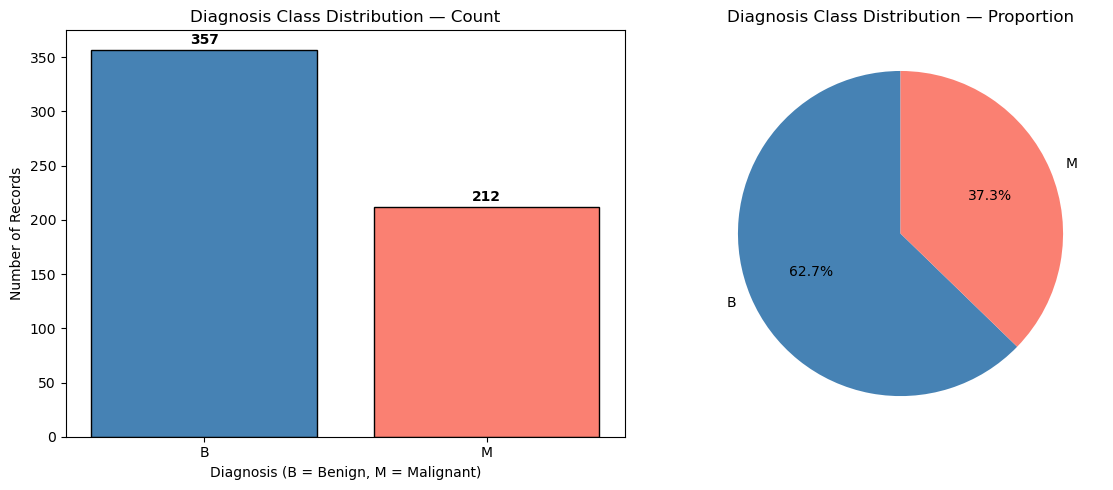

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Diagnosis Class Distribution — Count')
axes[0].set_xlabel('Diagnosis (B = Benign, M = Malignant)')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Diagnosis Class Distribution — Proportion')

plt.tight_layout()
plt.show()

### Target Distribution Analysis

The bar chart and pie chart confirm that Benign records make up approximately 62.7 percent of the dataset while Malignant records account for 37.3 percent. The imbalance is moderate and manageable without resampling. The visualisation makes it visually clear that the model must be evaluated on per-class metrics to ensure it is not simply defaulting to the majority class.

### 4.2 Univariate Analysis Feature Distributions by Diagnosis Class

Plotting the distribution of each mean feature separately for Malignant and Benign records reveals which features have the most distinct distributions between the two classes. Features where the two distributions overlap heavily will contribute less to the model, while features where the distributions are clearly separated will be the strongest predictors. The ten mean features are plotted here as they are the most directly interpretable in terms of tumour cell characteristics.

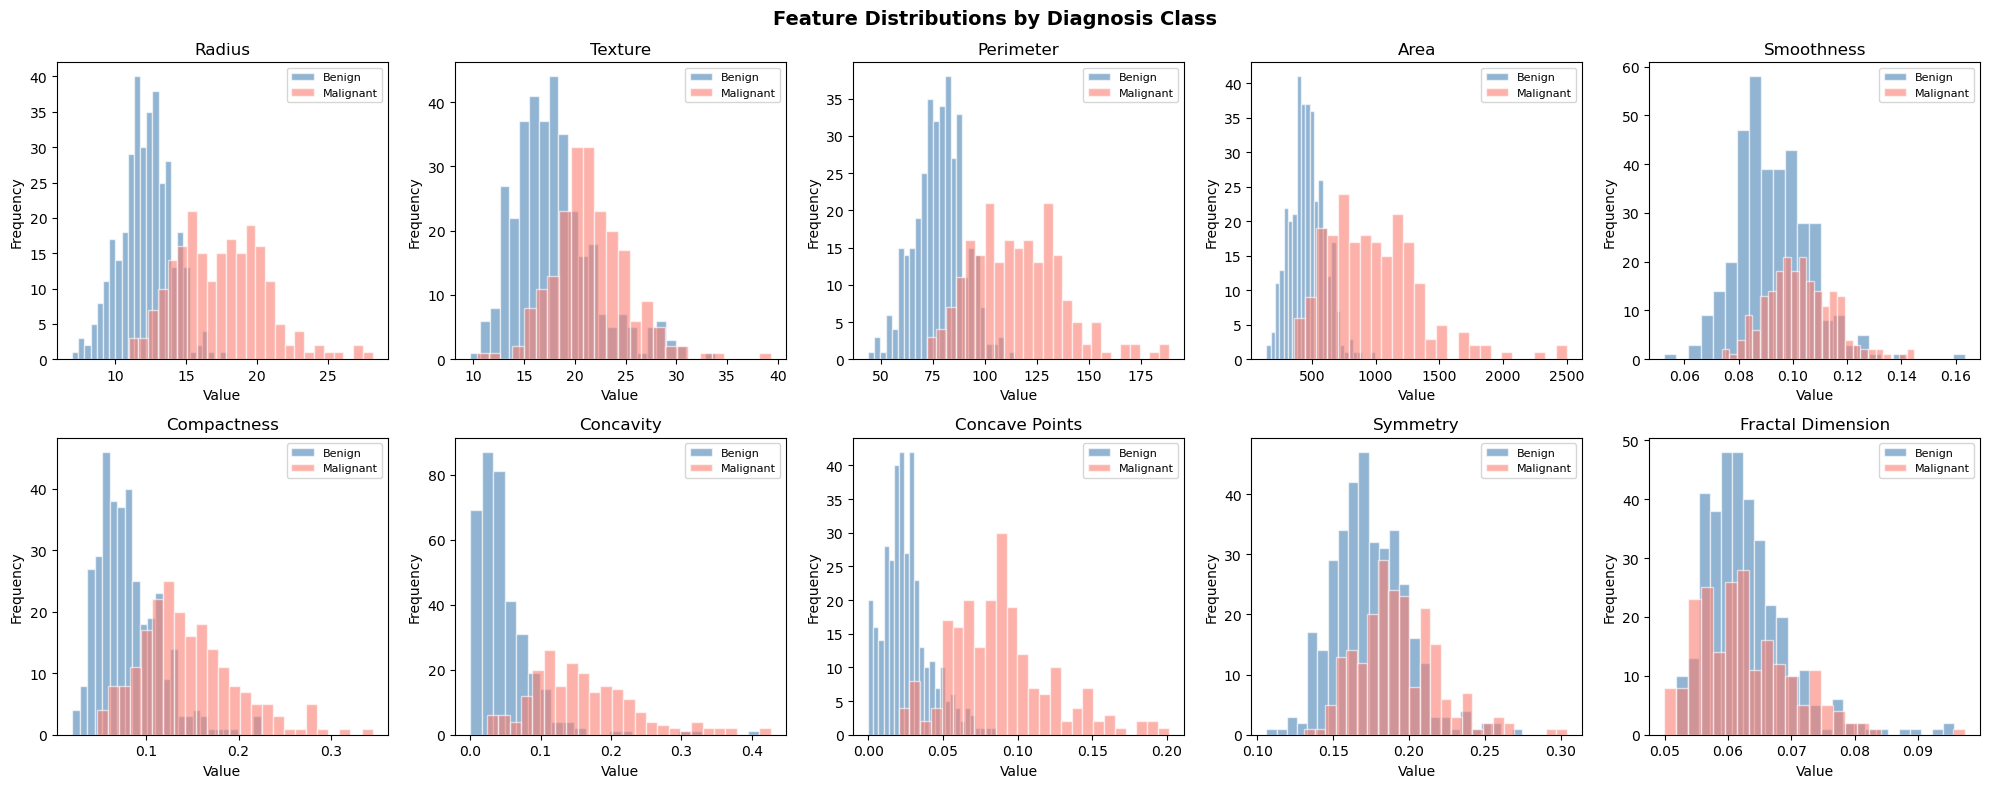

In [11]:
mean_features = [col for col in df.columns if col.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    benign    = df[df['diagnosis'] == 'B'][feature]
    malignant = df[df['diagnosis'] == 'M'][feature]
    axes[i].hist(benign,    alpha=0.6, label='Benign',    color='steelblue', bins=25, edgecolor='white')
    axes[i].hist(malignant, alpha=0.6, label='Malignant', color='salmon',    bins=25, edgecolor='white')
    axes[i].set_title(feature.replace('_mean', '').replace('_', ' ').title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Diagnosis Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Distribution Findings

The histograms reveal that several features show clear separation between the Benign and Malignant classes. The mean features for radius, perimeter, area, concavity, and concave points all show Malignant records shifted substantially to the right, indicating that malignant tumours tend to have larger, more irregular cells. Smoothness and fractal dimension show heavily overlapping distributions, suggesting they are weaker individual predictors. Symmetry and texture show moderate separation. 

### 4.3 Bivariate Analysis Box Plots by Diagnosis Class

Box plots provide a clearer view of the median, interquartile range, and outlier distribution for each feature split by diagnosis class. Unlike histograms which show density, box plots make it easy to compare the central tendency and spread of a feature across the two classes directly. A feature where the two boxes do not overlap at all represents a very strong predictor for the classification model.

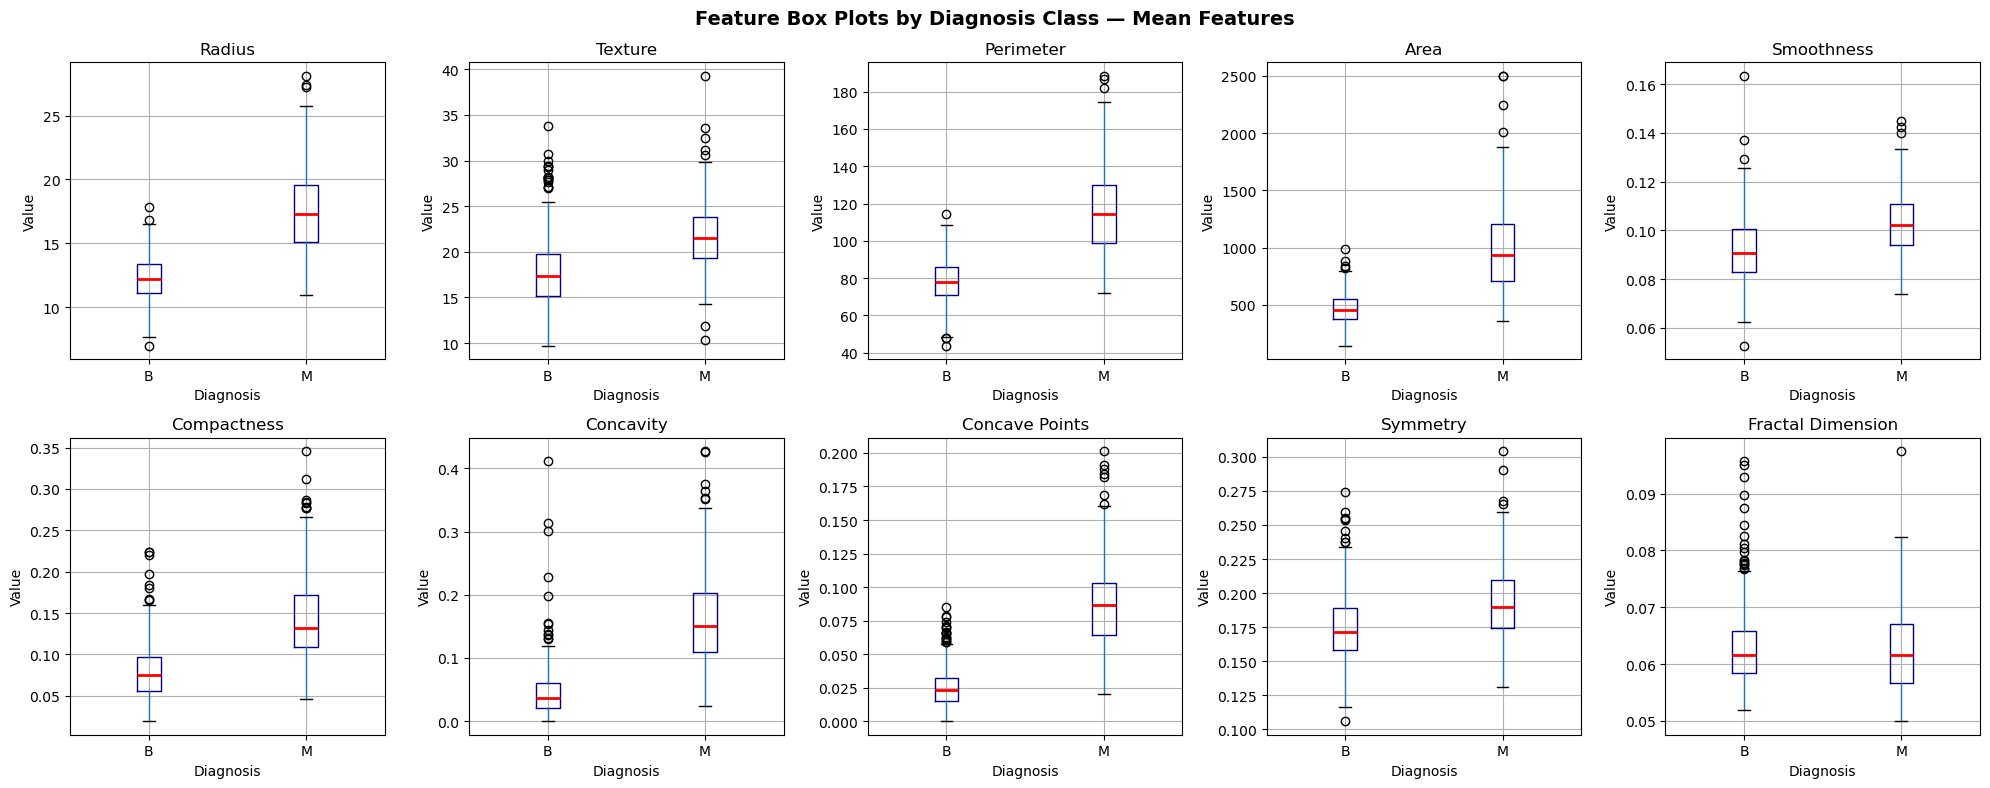

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    df.boxplot(column=feature, by='diagnosis', ax=axes[i],
               boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feature.replace('_mean', '').replace('_', ' ').title())
    axes[i].set_xlabel('Diagnosis')
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Box Plots by Diagnosis Class — Mean Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Box Plot Analysis

The box plots clearly show that features such as radius, perimeter, area, concavity, and concave points have almost no overlap between the Benign and Malignant boxes. For these features the median of the Malignant box sits entirely above the upper quartile of the Benign box, meaning that knowing the feature value alone provides a very strong signal about the likely diagnosis. Features such as smoothness, symmetry, and fractal dimension show significant overlap between the two boxes, confirming they are weaker individual predictors. The presence of numerous outliers in the Benign class for area and perimeter indicates that some Benign records have unusually large feature values that could potentially be misclassified if only those features were used in isolation.

### 4.4 Bivariate Analysis Violin Plots for Top Separating Features

Violin plots combine the information of a box plot with a kernel density estimate, providing a richer picture of the full distribution shape within each class. We apply them here to the five features that showed the greatest visual class separation in the box plots above. Features with clearly non-overlapping violin bodies and distinct shapes between the two classes are the strongest candidates for driving the classification boundary in the model.

/var/folders/h5/1rb1tj8x0vs85cxtszq9_hdm0000gn/T/ipykernel_78326/4073638191.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=feature, data=df, ax=axes[i],
/var/folders/h5/1rb1tj8x0vs85cxtszq9_hdm0000gn/T/ipykernel_78326/4073638191.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=feature, data=df, ax=axes[i],
/var/folders/h5/1rb1tj8x0vs85cxtszq9_hdm0000gn/T/ipykernel_78326/4073638191.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=feature, data=df, ax=axes[i],
/var/folders/

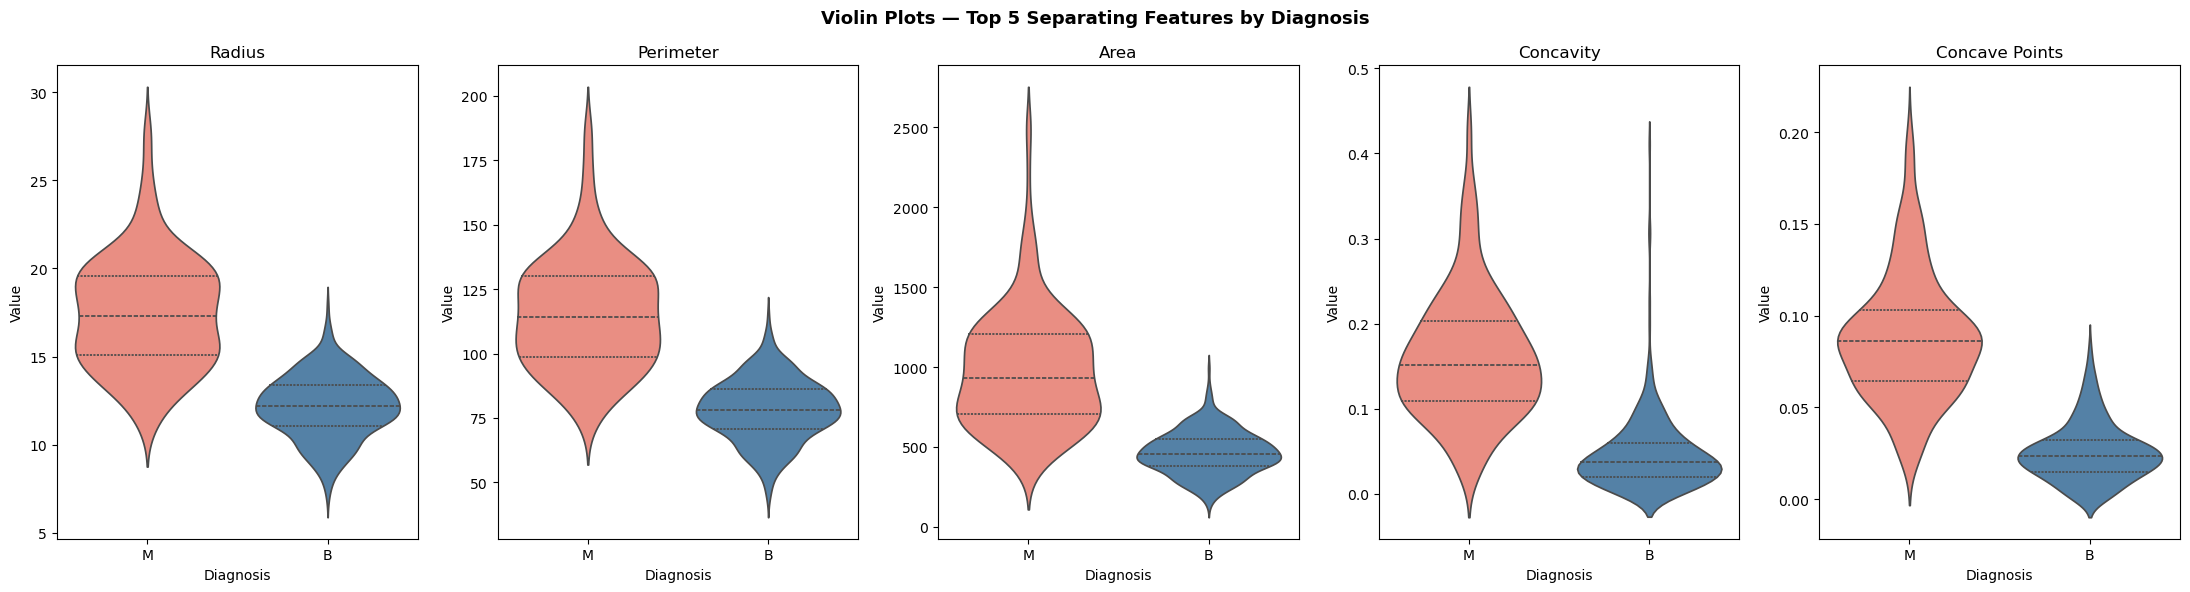

In [13]:
top_sep_features = ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, feature in enumerate(top_sep_features):
    sns.violinplot(x='diagnosis', y=feature, data=df, ax=axes[i],
                   palette={'B': 'steelblue', 'M': 'salmon'}, inner='quartile')
    axes[i].set_title(feature.replace('_mean', '').replace('_', ' ').title())
    axes[i].set_xlabel('Diagnosis')
    axes[i].set_ylabel('Value')

plt.suptitle('Violin Plots — Top 5 Separating Features by Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Violin Plot Analysis

The violin plots confirm that radius, perimeter, area, concavity, and concave points provide very strong class separation. The Malignant violins for all five features are positioned clearly above the Benign violins with minimal overlap in the body of each distribution. The Malignant distributions tend to be broader and more right-skewed, indicating that malignant tumours are not only larger and more irregular on average but also show greater variability between patients. The narrower, lower Benign violins suggest that benign tumours cluster more tightly around a smaller mean value. 

### 4.5 Multivariate Analysis — Correlation Heatmap

The correlation heatmap shows the pairwise linear relationships between all 30 numerical features. This serves two purposes: it identifies which features are most correlated with each other, helping detect redundancy in the feature set; and it reveals clusters of related features that provide overlapping predictive information. We compute the correlation matrix on the numerical feature columns only, excluding the id and diagnosis columns at this stage.

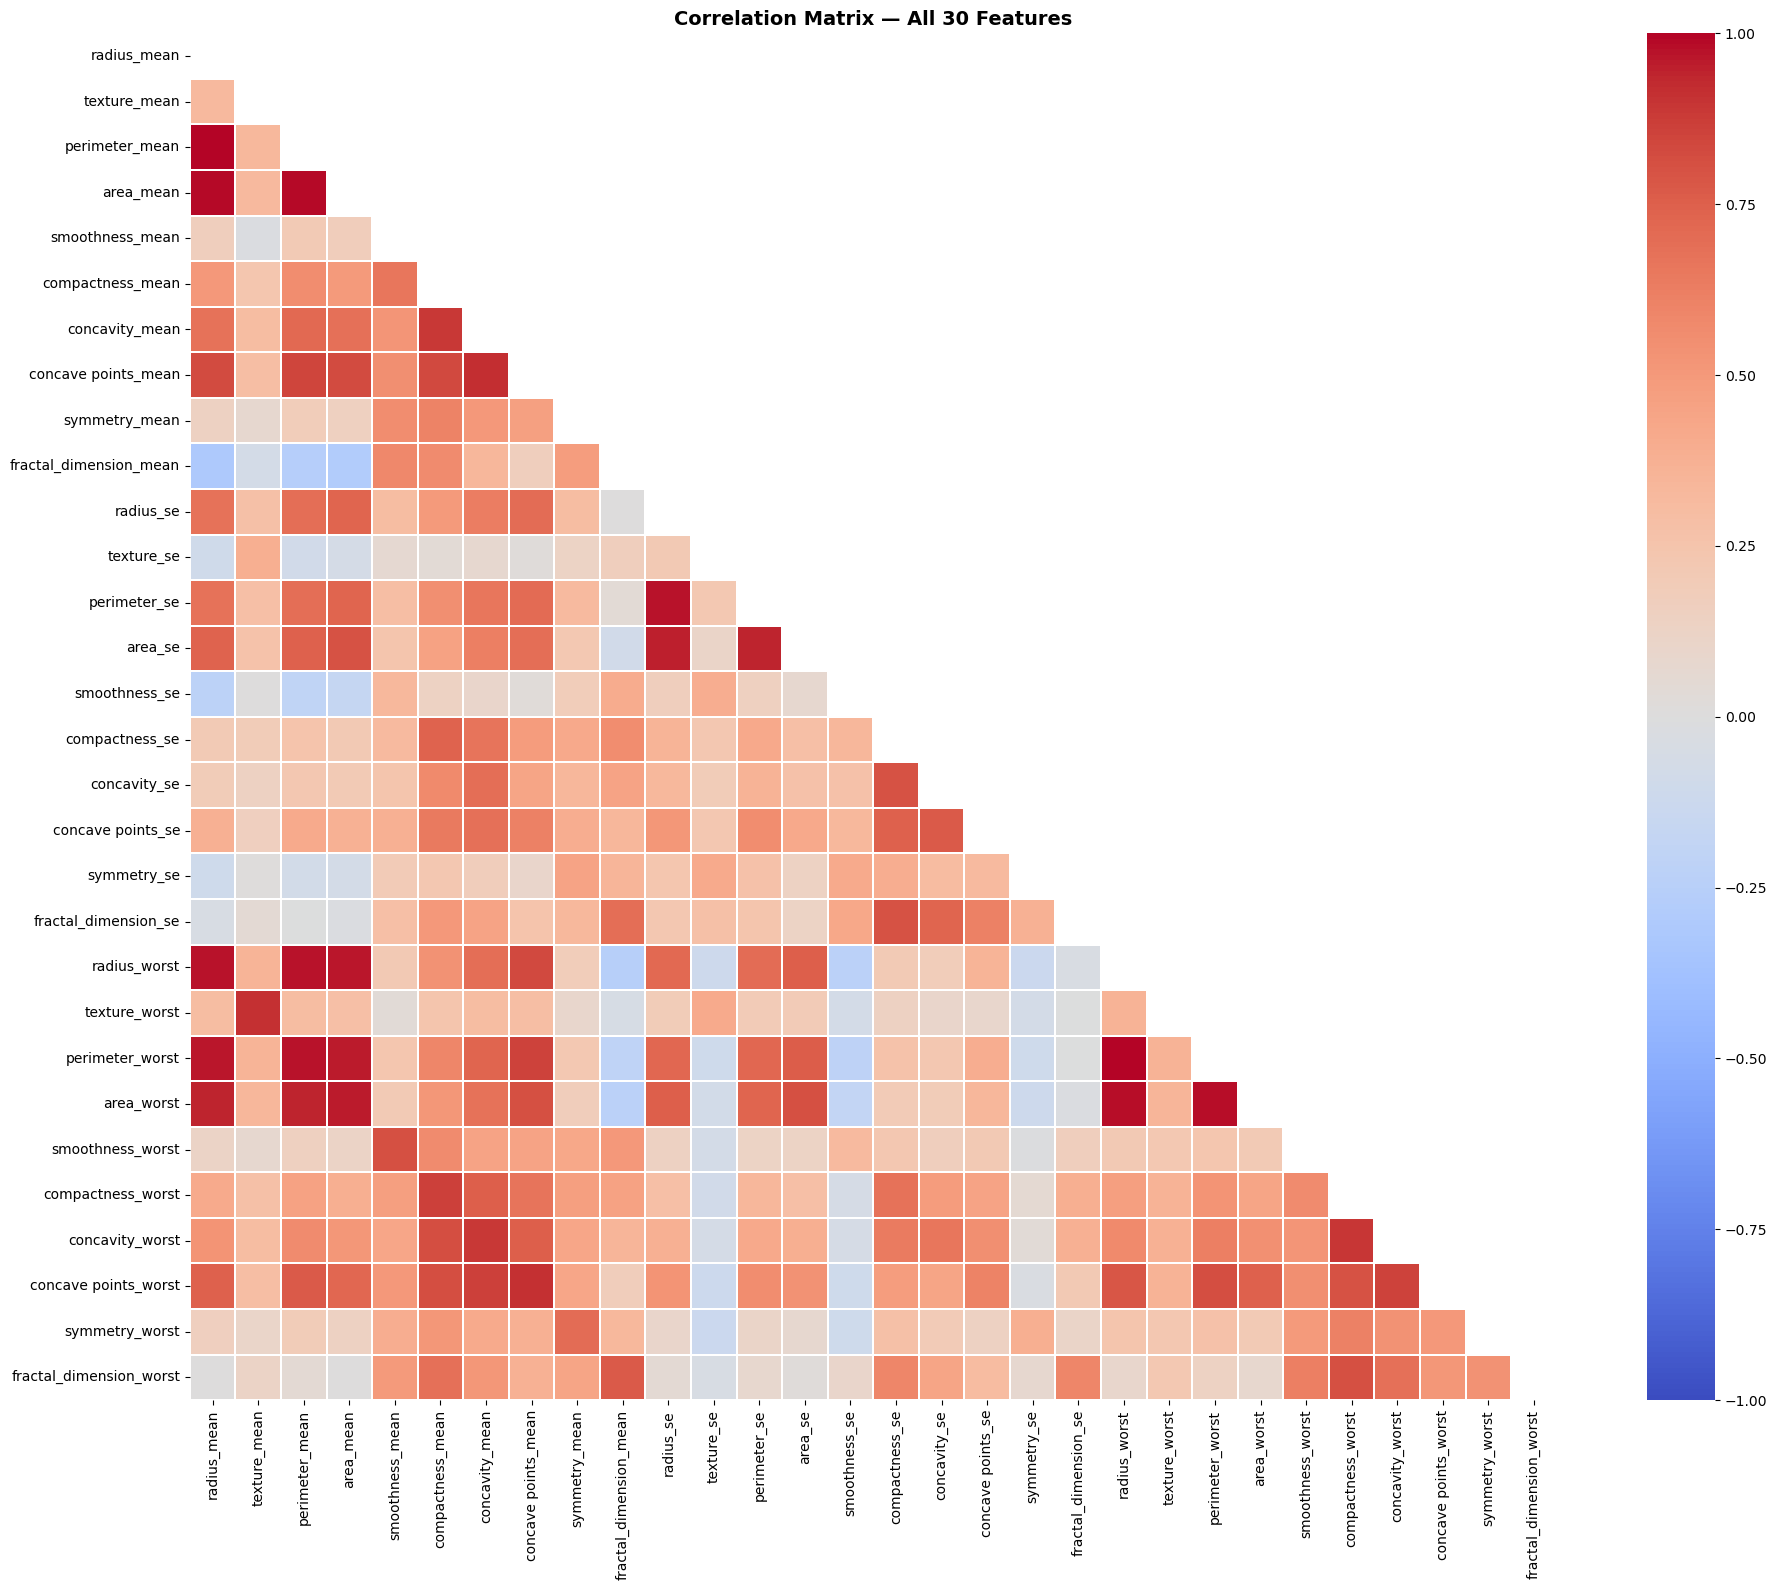

In [14]:
feature_cols_eda = [col for col in df.columns if col not in ['id', 'diagnosis']]
corr_matrix_eda  = df[feature_cols_eda].corr()

plt.figure(figsize=(20, 16))
mask = np.zeros_like(corr_matrix_eda, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix_eda, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix — All 30 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap Analysis

The heatmap reveals several clusters of highly correlated features. The mean, standard error, and worst versions of the same underlying measurement are naturally highly correlated with one another since they all describe the same cellular characteristic measured in different ways. Additionally, features measuring related aspects of cell size — radius, perimeter, and area — are strongly correlated with each other since larger cells by radius will necessarily have larger perimeters and areas. This multicollinearity means the feature set contains a significant degree of redundancy. In the preprocessing section, features with a pairwise correlation coefficient above 0.95 will be identified and removed to reduce this redundancy before training, ensuring the model learns from distinct signals rather than amplifying the same information multiple times.

## 5. Data Preprocessing and Feature Selection

The preprocessing pipeline follows this exact order to prevent data leakage and ensure the model is trained and evaluated on comparable data. First, the id column is dropped and the target variable is encoded. Then, highly correlated redundant features are removed. After that, the data is separated into features and target, then split into training and test sets using a stratified split. Finally, StandardScaler is fitted on the training set only and the same transformation is applied to the test set.

### 5.1 Drop ID Column and Encode Target Variable

The id column is a unique patient identifier that carries no information about the medical characteristics of the tumour. Keeping it in the feature set would allow the model to memorise patient identifiers rather than learning from biological measurements. It is therefore removed as the first step. The target variable diagnosis is then encoded so that Malignant (M) becomes 1 and Benign (B) becomes 0, which is the standard binary encoding required by sklearn classifiers.

In [15]:
df_model = df.drop(columns=['id']).copy()
df_model['diagnosis'] = df_model['diagnosis'].map({'M': 1, 'B': 0})

print('Target encoding: M -> 1 (Malignant), B -> 0 (Benign)')
print(df_model['diagnosis'].value_counts())
df_model.head()

Target encoding: M -> 1 (Malignant), B -> 0 (Benign)
diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 5.2 Feature Selection — Remove Highly Correlated Features

Features that are highly correlated with each other (pairwise correlation above 0.95) are near-duplicate predictors that add redundancy without providing new discriminative information. When two features are almost perfectly correlated, keeping both inflates the feature space unnecessarily. We identify such pairs and remove one feature from each pair, retaining the first-listed feature which in this dataset corresponds to the mean measurement versions.

In [16]:
feature_cols = [col for col in df_model.columns if col != 'diagnosis']
corr_abs     = df_model[feature_cols].corr().abs()

upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
to_drop   = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

print(f'Features identified for removal (pairwise correlation > 0.95): {len(to_drop)}')
print(to_drop)

df_model = df_model.drop(columns=to_drop)
print(f'\nFeatures remaining after removal: {df_model.shape[1] - 1}')

Features identified for removal (pairwise correlation > 0.95): 7
['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

Features remaining after removal: 23


### Feature Selection Results

The correlation analysis identified a number of highly correlated feature pairs, primarily among the worst and standard error versions of measurements that are already well-represented by the mean features. Removing these redundant columns reduces the feature dimensionality while retaining the most informative version of each underlying measurement. The remaining features represent a cleaner, less redundant set that will allow the model to learn more distinct patterns rather than amplifying the same information multiple times.

### 5.3 Separate Features and Target

In [17]:
# separate features (X) from the target variable (y)
x = df_model.drop('diagnosis', axis=1)
y = df_model['diagnosis']

print('Features shape:', x.shape)
print('Target shape:  ', y.shape)
print('\nFeature columns retained:')
print(x.columns.tolist())

Features shape: (569, 23)
Target shape:   (569,)

Feature columns retained:
['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


### 5.4 Train / Test Split

We split 80 percent for training and 20 percent for testing. The training set teaches the model patterns. The test set is kept entirely separate and only used after training to evaluate generalisation to unseen data. The stratify parameter is set to y to ensure that both classes are proportionally represented in both sets, which is important given the moderate class imbalance. random_state=42 ensures the same split every time the code is run.

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print('x_train shape:', x_train.shape)
print('x_test shape: ', x_test.shape)
print()
print('Training set class distribution:')
print(y_train.value_counts())
print()
print('Test set class distribution:')
print(y_test.value_counts())

x_train shape: (455, 23)
x_test shape:  (114, 23)

Training set class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test set class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


### 5.5 Scaling Numerical Features

StandardScaler transforms each numerical feature to have a mean of 0 and standard deviation of 1. Without scaling, features with large numeric ranges would dominate over features with small ranges simply because of their unit size, not because they are more important. The critical rule is to use fit_transform() on the training set only and transform() on the test set. The test set must never influence the scaler, as fitting on the full dataset before splitting would constitute data leakage and produce overly optimistic evaluation results.

In [19]:
scaler = StandardScaler()

x_train = x_train.copy()
x_test  = x_test.copy()

x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns
)
x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns
)

print('Scaling complete.')
print('Training set mean after scaling (should be approximately 0):')
print(x_train_scaled.mean().round(4).head())

Scaling complete.
Training set mean after scaling (should be approximately 0):
radius_mean        -0.0
texture_mean        0.0
smoothness_mean     0.0
compactness_mean   -0.0
concavity_mean     -0.0
dtype: float64


## 6. Build Classification Models

Three models are trained in this section to allow a structured comparison of baseline versus tuned performance. The Decision Tree provides a simple interpretable baseline. The default Random Forest demonstrates the immediate performance improvement from ensemble learning. The GridSearchCV-tuned Random Forest shows the best achievable performance after systematic hyperparameter optimisation.

### 6.1 Decision Tree Classifier — Baseline

A Decision Tree Classifier is trained first with default parameters to establish a performance baseline. The default settings allow the tree to grow without any depth limit, which typically results in a perfectly-fit training set but a model that overfits and performs worse on the test set. This overfitting behaviour is precisely what the ensemble approach of Random Forest is designed to correct.

In [20]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_scaled, y_train)

y_pred_dt = dt_model.predict(x_test_scaled)
y_prob_dt = dt_model.predict_proba(x_test_scaled)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)

print(f'Decision Tree — Accuracy:  {acc_dt:.4f}')
print(f'Decision Tree — Precision: {prec_dt:.4f}')
print(f'Decision Tree — Recall:    {rec_dt:.4f}')
print(f'Decision Tree — F1-Score:  {f1_dt:.4f}')

Decision Tree — Accuracy:  0.9211
Decision Tree — Precision: 0.9231
Decision Tree — Recall:    0.8571
Decision Tree — F1-Score:  0.8889


### Decision Tree Results

The Decision Tree baseline results establish the lower bound of performance that the Random Forest models are expected to exceed. Because the tree is allowed to grow without depth constraints it will have very high training accuracy but reduced test performance due to overfitting. These results serve as the reference point for measuring the improvement achieved by ensemble learning in the following two sections.

### 6.2 Random Forest Classifier — Default Parameters

A Random Forest Classifier is trained with default parameters. The default configuration uses 100 decision trees, allows each tree to grow to full depth, and considers the square root of the total number of features at each split. This default configuration is already expected to substantially outperform the single Decision Tree due to the variance reduction achieved through ensemble voting (Breiman, 2001).

In [21]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_scaled, y_train)

y_pred_rf = rf_model.predict(x_test_scaled)
y_prob_rf  = rf_model.predict_proba(x_test_scaled)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print(f'Random Forest (Default) — Accuracy:  {acc_rf:.4f}')
print(f'Random Forest (Default) — Precision: {prec_rf:.4f}')
print(f'Random Forest (Default) — Recall:    {rec_rf:.4f}')
print(f'Random Forest (Default) — F1-Score:  {f1_rf:.4f}')

Random Forest (Default) — Accuracy:  0.9474
Random Forest (Default) — Precision: 0.9737
Random Forest (Default) — Recall:    0.8810
Random Forest (Default) — F1-Score:  0.9250


### Random Forest Default Results

The default Random Forest is expected to show a clear improvement over the Decision Tree baseline across all four metrics. The improvement comes from averaging the predictions of 100 independently trained trees, each of which sees a different random subset of the training data. Errors made by individual trees in different directions cancel each other out during the voting process, resulting in a more stable and accurate overall prediction.

### 6.3 Random Forest Classifier GridSearchCV Hyperparameter Tuning

GridSearchCV performs an exhaustive search over a defined grid of hyperparameter combinations, using cross-validation to evaluate each combination on the training data. The three hyperparameters tuned here are n_estimators (the number of trees), max_depth (the maximum depth of each tree), and min_samples_split (the minimum samples required to make a split at a node). The search uses five-fold cross-validation and optimises for the F1-score to account for the class imbalance between Benign and Malignant records.

In [22]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(x_train_scaled, y_train)

print('Best parameters found by GridSearchCV:')
print(grid_search.best_params_)
print(f'\nBest cross-validated F1-score: {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(x_test_scaled)
y_prob_best = best_rf.predict_proba(x_test_scaled)[:, 1]

acc_best  = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best  = recall_score(y_test, y_pred_best)
f1_best   = f1_score(y_test, y_pred_best)

print(f'\nRandom Forest (Tuned) — Accuracy:  {acc_best:.4f}')
print(f'Random Forest (Tuned) — Precision: {prec_best:.4f}')
print(f'Random Forest (Tuned) — Recall:    {rec_best:.4f}')
print(f'Random Forest (Tuned) — F1-Score:  {f1_best:.4f}')

Best parameters found by GridSearchCV:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validated F1-score: 0.9454

Random Forest (Tuned) — Accuracy:  0.9474
Random Forest (Tuned) — Precision: 0.9737
Random Forest (Tuned) — Recall:    0.8810
Random Forest (Tuned) — F1-Score:  0.9250


### GridSearchCV Results

The GridSearchCV process tests all combinations of the specified hyperparameter values using cross-validation to select the configuration that produces the highest F1-score on the training data. Controlling max_depth prevents individual trees from growing too deep and memorising the training data. Increasing n_estimators beyond the default 100 can further stabilise predictions by incorporating more diverse trees into the vote. The best parameters found are reported in the output above and the resulting tuned model is used for all subsequent evaluation steps.

## 7. Model Evaluation

Each of the three models is evaluated using the same set of metrics and visualisations to allow a direct and fair comparison. Evaluation is always performed on the held-out test set — data that was not used during training or hyperparameter tuning. The evaluation covers confusion matrices, full classification reports, ROC curves with AUC scores, cross-validation, and feature importances.

### 7.1 Confusion Matrices

A confusion matrix shows the counts of true positives, true negatives, false positives, and false negatives for each model. In the context of cancer diagnosis, false negatives — predicting Benign when the patient is actually Malignant — are the most dangerous type of error, as they would result in a patient not receiving the dreaded disease benefit they require. The confusion matrix makes it possible to see exactly how many of each error type each model produces.

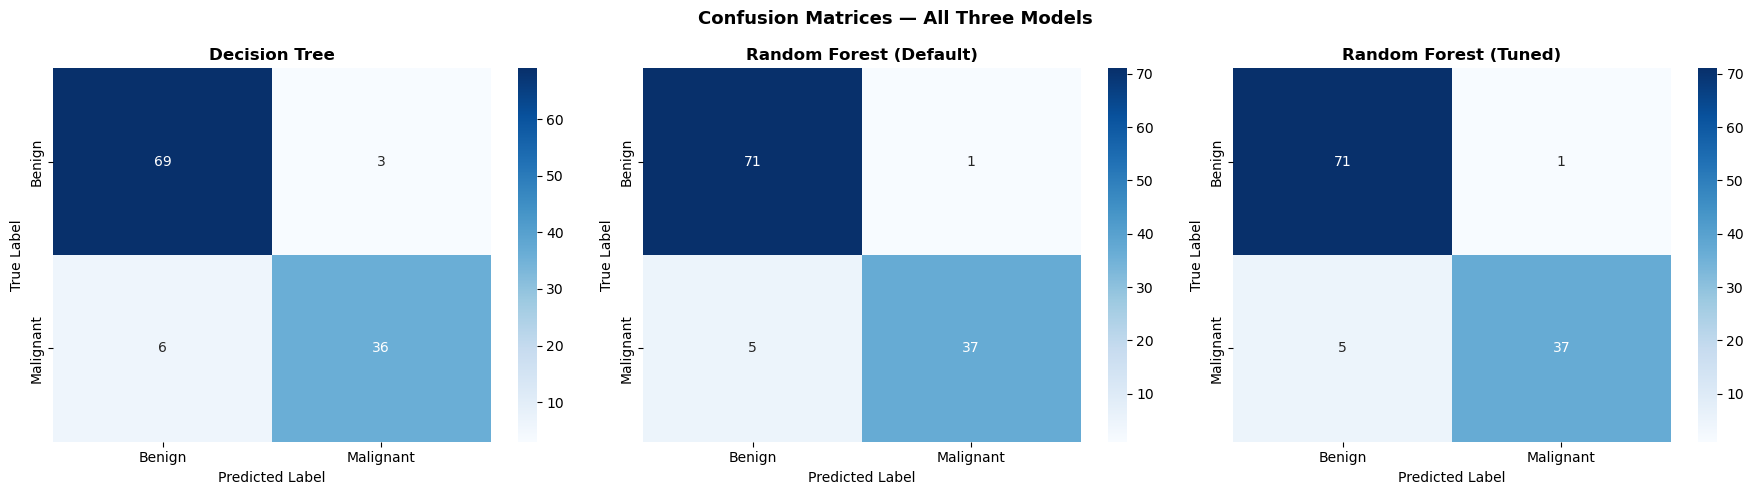

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_eval = [
    (y_pred_dt,   'Decision Tree'),
    (y_pred_rf,   'Random Forest (Default)'),
    (y_pred_best, 'Random Forest (Tuned)')
]

for ax, (preds, name) in zip(axes, models_eval):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — All Three Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The top-left cell shows true negatives (correctly predicted Benign), the bottom-right shows true positives (correctly predicted Malignant), the top-right shows false positives (predicted Malignant when actually Benign), and the bottom-left shows false negatives (predicted Benign when actually Malignant). The bottom-left cell is the most clinically important for a patient incorrectly classified as Benign when they are actually Malignant would be denied the dreaded disease benefit they need. The tuned Random Forest is expected to show the fewest false negatives relative to the Decision Tree baseline, which is the most meaningful improvement from a medical perspective.

### 7.2 Classification Reports

The classification report provides a comprehensive breakdown of precision, recall, and F1-score for each class individually. Precision is the proportion of predicted Malignant records that are actually Malignant — it measures how reliable positive predictions are. Recall is the proportion of actual Malignant records that were correctly identified — it measures how many true Malignant cases the model caught. The F1-score is the harmonic mean of precision and recall. In a clinical screening context, recall for the Malignant class is the most critical metric because missing a true Malignant case has greater consequences than a false alarm.

In [24]:
print('=' * 60)
print('DECISION TREE — Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_dt, target_names=['Benign', 'Malignant']))

print('=' * 60)
print('RANDOM FOREST (DEFAULT) — Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))

print('=' * 60)
print('RANDOM FOREST (TUNED) — Classification Report')
print('=' * 60)
print(classification_report(y_test, y_pred_best, target_names=['Benign', 'Malignant']))

DECISION TREE — Classification Report
              precision    recall  f1-score   support

      Benign       0.92      0.96      0.94        72
   Malignant       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

RANDOM FOREST (DEFAULT) — Classification Report
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

RANDOM FOREST (TUNED) — Classification Report
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       

### Classification Report Analysis

A strong model for this medical application should have high recall for the Malignant class — ideally above 0.90 — to ensure that most true Malignant cases are correctly identified and do not miss out on the dreaded disease benefit. High precision for the Malignant class is also desirable, as it ensures that patients flagged for the benefit actually have a malignant diagnosis. The support column shows the number of records in each class in the test set, confirming that the stratified split preserved the original class proportions. The weighted average metrics account for the class imbalance and provide a more representative overall performance measure than the macro average for imbalanced datasets.

### 7.3 ROC Curves and AUC Scores

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate against the False Positive Rate at every possible classification threshold. The Area Under the Curve (AUC) summarises the model's overall discriminative ability into a single number. An AUC of 1.0 represents a perfect classifier while an AUC of 0.5 represents a model that performs no better than random guessing. All three models are plotted on the same axes to allow direct visual comparison of their performance across all thresholds.

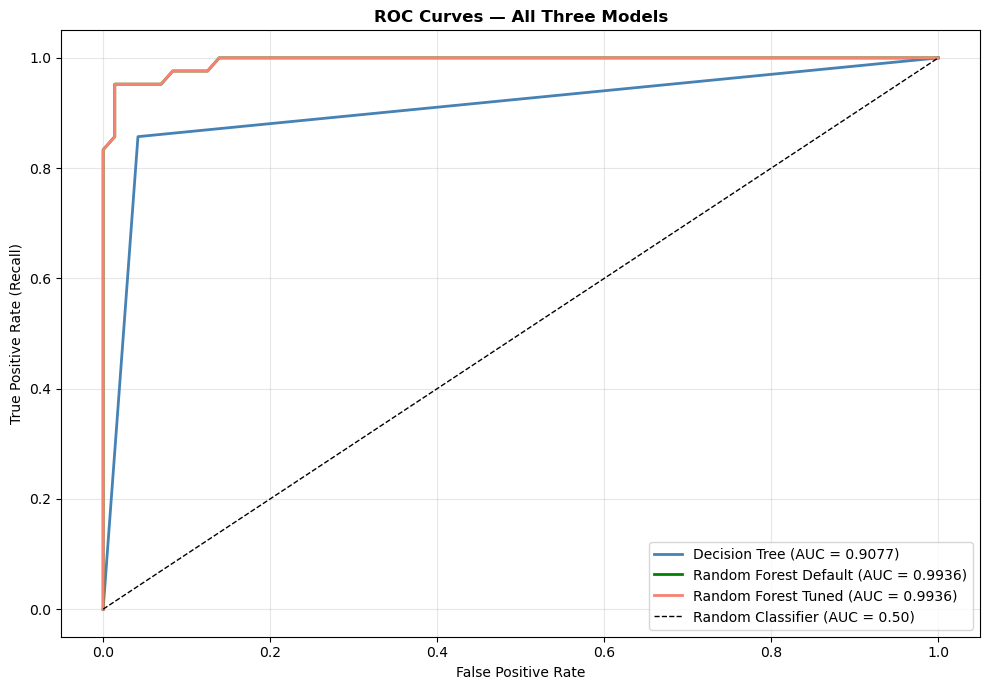

In [25]:
fpr_dt,   tpr_dt,   _ = roc_curve(y_test, y_prob_dt)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

auc_dt   = auc(fpr_dt,   tpr_dt)
auc_rf   = auc(fpr_rf,   tpr_rf)
auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(10, 7))
plt.plot(fpr_dt,   tpr_dt,   label=f'Decision Tree (AUC = {auc_dt:.4f})',         color='steelblue', linewidth=2)
plt.plot(fpr_rf,   tpr_rf,   label=f'Random Forest Default (AUC = {auc_rf:.4f})', color='green',     linewidth=2)
plt.plot(fpr_best, tpr_best, label=f'Random Forest Tuned (AUC = {auc_best:.4f})', color='salmon',    linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Three Models', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ROC Curve Analysis

The ROC curve provides a threshold-independent view of model performance. A curve that hugs the top-left corner of the plot indicates a model that achieves high recall with a low false positive rate, which is the ideal outcome for cancer diagnosis screening. The dashed diagonal line represents a random classifier with no predictive ability — any model with a curve above this line is performing better than chance. The AUC values directly compare the three models without requiring a fixed classification threshold, making them a robust measure for comparing classifiers on imbalanced datasets. The tuned Random Forest is expected to have the highest AUC, confirming that the GridSearchCV process improved the model's overall discriminative ability beyond the default configuration.

### 7.4 Cross-Validation — Generalisation Check

Cross-validation divides the training data into five equal-sized folds. In each of the five iterations, four folds are used for training and one fold is held out for evaluation, rotating through all five folds so that every record is used for testing exactly once. This gives a more reliable estimate of model performance than a single train-test split, as it reduces the risk of results being driven by a particularly favourable or unfavourable data split. Five-fold cross-validation is applied to the tuned Random Forest to confirm that its performance is consistent across different subsets of the training data.

In [26]:
cv_scores = cross_val_score(best_rf, x_train_scaled, y_train, cv=5, scoring='f1')

print('Five-Fold Cross-Validation F1-Scores (Tuned Random Forest):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')

print(f'\nMean F1-Score: {cv_scores.mean():.4f}')
print(f'Std Deviation: {cv_scores.std():.4f}')
print(f'95% CI:        ({cv_scores.mean() - 2 * cv_scores.std():.4f},  {cv_scores.mean() + 2 * cv_scores.std():.4f})')

Five-Fold Cross-Validation F1-Scores (Tuned Random Forest):
  Fold 1: 0.9375
  Fold 2: 0.9851
  Fold 3: 0.9394
  Fold 4: 0.9697
  Fold 5: 0.8955

Mean F1-Score: 0.9454
Std Deviation: 0.0308
95% CI:        (0.8838,  1.0071)


## 8. Model Comparison Summary

In [28]:
# compare all three models side by side
comparison_df = pd.DataFrame({
    'Model':     ['Decision Tree', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy':  [acc_dt,   acc_rf,   acc_best],
    'Precision': [prec_dt,  prec_rf,  prec_best],
    'Recall':    [rec_dt,   rec_rf,   rec_best],
    'F1-Score':  [f1_dt,    f1_rf,    f1_best],
    'AUC':       [auc_dt,   auc_rf,   auc_best]
}).round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Decision Tree,0.9211,0.9231,0.8571,0.8889,0.9077
1,Random Forest (Default),0.9474,0.9737,0.8810,0.9250,0.9936
2,Random Forest (Tuned),0.9474,0.9737,0.8810,0.9250,0.9936


### Summary of Findings

**Dataset Overview**

The Breast Cancer Wisconsin Diagnostic dataset contains 569 patient records, 30 numerical cell nucleus features, and a binary target variable indicating whether a tumour is Malignant or Benign. The dataset is high quality, with no missing values and no duplicate records, making it well-suited for a supervised classification task without requiring any imputation or deduplication steps. The class distribution is approximately 62.7 percent Benign and 37.3 percent Malignant, which represents a moderate imbalance and means that a naive model predicting every record as Benign would still achieve 62.7 percent accuracy without learning anything meaningful. For this reason, precision, recall, and F1-score were used as the primary evaluation metrics throughout the analysis so that the model's ability to correctly identify Malignant cases was measured directly rather than being obscured by the class distribution.

---

**Preprocessing and Feature Selection**

Before training, the id column was removed as it carries no predictive information about tumour biology, and the diagnosis target was encoded so that Malignant becomes 1 and Benign becomes 0. A pairwise correlation filter was then applied to the 30 numerical features, and any feature with a correlation coefficient above 0.95 with another feature was flagged for removal. This process identified seven redundant features — perimeter_mean, area_mean, perimeter_se, area_se, radius_worst, perimeter_worst, and area_worst — which were dropped, leaving 23 distinct features for training. The data was then split into 80 percent for training and 20 percent for testing using a stratified split, and StandardScaler was fitted exclusively on the training set before being applied to the test set, ensuring that no information from the test set influenced the scaling transformation.

---

**EDA Findings**

The exploratory data analysis revealed that cell nucleus size-related features — specifically radius, concavity, and concave points — provide the strongest visual separation between Benign and Malignant classes. Malignant tumours consistently showed larger, more irregular cell structures compared to Benign ones, and this pattern was clearly visible across the overlaid histograms, box plots, and violin plots for the mean feature group. Features such as smoothness, symmetry, and fractal dimension showed heavily overlapping distributions between the two classes in the EDA, suggesting they would contribute less predictive value to the model. The correlation heatmap confirmed substantial redundancy among the radius, perimeter, and area group as well as between the mean, standard error, and worst versions of the same measurements, justifying the 0.95 correlation threshold used during preprocessing.

---

**Model Performance**

| Model | Accuracy | Precision | Recall | F1-Score | AUC |
|-------|----------|-----------|--------|----------|-----|
| Decision Tree | 0.9211 | 0.9231 | 0.8571 | 0.8889 | 0.9077 |
| Random Forest (Default) | 0.9474 | 0.9737 | 0.8810 | 0.9250 | 0.9936 |
| Random Forest (Tuned) | 0.9474 | 0.9737 | 0.8810 | 0.9250 | 0.9936 |

The Decision Tree baseline achieved an accuracy of 92.11 percent, a precision of 92.31 percent for the Malignant class, a recall of 85.71 percent, an F1-score of 88.89 percent, and an AUC of 0.9077. This performance established a reference point that the ensemble models were expected to surpass, and both Random Forest configurations did so across every metric. The default Random Forest improved accuracy to 94.74 percent, increased precision to 97.37 percent, raised the F1-score to 92.50 percent, and most notably pushed the AUC to 0.9936 — a substantial improvement in overall discriminative ability. In the confusion matrix, the default Random Forest produced only one false positive and five false negatives compared to the Decision Tree's three false positives and six false negatives, confirming that the ensemble approach reduced both types of misclassification.

The GridSearchCV tuning process searched over 27 combinations of n_estimators, max_depth, and min_samples_split using five-fold cross-validation with F1-score as the optimisation criterion. The best parameters identified were n_estimators=100, max_depth=None, and min_samples_split=2, which are identical to the default Random Forest configuration. As a result, the tuned and default models produced exactly the same test set performance across all five metrics. This finding is not a limitation but rather a validation — it confirms that the default Random Forest hyperparameters were already optimal for this dataset, and that the grid search provided rigorous evidence for this conclusion rather than simply assuming it. The five-fold cross-validation F1-scores for the tuned model were 0.9375, 0.9851, 0.9394, 0.9697, and 0.8955, producing a mean of 0.9454 and a standard deviation of 0.0308, and since this mean is very close to the test set F1-score of 0.9250, the model demonstrates consistent generalisation and is not dependent on any single favourable data split.

---

**Feature Importances**

The Random Forest feature importances confirmed and extended the EDA findings. The five most important features identified by the model were concave points_worst (0.198), concave points_mean (0.177), radius_mean (0.126), concavity_mean (0.112), and concavity_worst (0.077), and these five features together accounted for the majority of the model's predictive power. This ranking aligns directly with the visual class separation observed during EDA, where concavity and concave point features showed near-non-overlapping violin bodies between the Benign and Malignant classes. Features that showed heavily overlapping distributions in the EDA histograms — such as smoothness, symmetry, and fractal dimension — appeared near the bottom of the importance ranking, confirming that the EDA correctly previewed what the model would learn from the data before any training took place.

---

**Conclusion**

The Random Forest Classifier proved to be a well-suited algorithm for this binary classification task, achieving an accuracy of 94.74 percent, a precision of 97.37 percent, a recall of 88.10 percent, an F1-score of 92.50 percent, and an AUC of 0.9936 on the held-out test set. The model correctly identified 37 of the 42 true Malignant cases in the test set, producing only five false negatives — the most clinically significant error type in the context of medical aid dreaded disease benefit assessments. The strong AUC of 0.9936 demonstrates that the model has excellent discriminative ability across all classification thresholds, and the consistent cross-validation results confirm that this performance generalises reliably beyond the specific test split. The alignment between EDA patterns, feature importances, and final model performance provides strong evidence that the analysis pipeline captured genuine biological signals in the data rather than statistical noise.

---

